# 公式 o3 — Dual Phosphorylation Cycle（二重リン酸化サイクル）

> **出典（E-Cell4 公式）**: Examples → *Dual Phosphorylation Cycle* — https://ecell4.e-cell.org/examples/example03.html
>
> E-Cell4 公式例題の移植。公式コードをそのまま使う（プロットのみ matplotlib）。

**この例が教えること**: **状態を持つタンパク質**（未修飾 K / 一リン酸化 Kp / 二リン酸化 Kpp）と酵素（キナーゼ KK・脱リン酸化酵素 PP）の
**酵素反応カスケード**を、`@species_attributes` / `@reaction_rules` の**デコレータ**と `Session` で書く。MAPK 型シグナルの典型モチーフ。

**公式からの注記**: 公式ページのコードは `rulegen(ka1, kd2, kcat1, ka2, kd2, kcat2)` と `kd2` が重複（`kd1` 未使用）——ドキュメントの誤植と判断し、
ここでは `rulegen(ka1, kd1, kcat1, ka2, kd2, kcat2)` に直している。

In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from ecell4.prelude import *

@species_attributes
def attrgen(radius, D):
    K | Kp | Kpp | KK | PP | K_KK | Kp_KK | Kpp_PP | Kp_PP | {'radius': radius, 'D': D}

@reaction_rules
def rulegen(kon1, koff1, kcat1, kon2, koff2, kcat2):
    (K + KK == K_KK | (kon1, koff1)
        > Kp + KK | kcat1
        == Kp_KK | (kon2, koff2)
        > Kpp + KK | kcat2)
    (Kpp + PP == Kpp_PP | (kon1, koff1)
        > Kp + PP | kcat1
        == Kp_PP | (kon2, koff2)
        > K + PP | kcat2)

radius, D = 0.0025, 1.0
ka1, kd1, kcat1 = 0.04483455086786913, 1.35, 1.5
ka2, kd2, kcat2 = 0.09299017957780264, 1.73, 15.0

m = NetworkModel()
m.add_species_attributes(attrgen(radius, D))
m.add_reaction_rules(rulegen(ka1, kd1, kcat1, ka2, kd2, kcat2))
session = Session(model=m, y0={'K': 120, 'KK': 30, 'PP': 30})

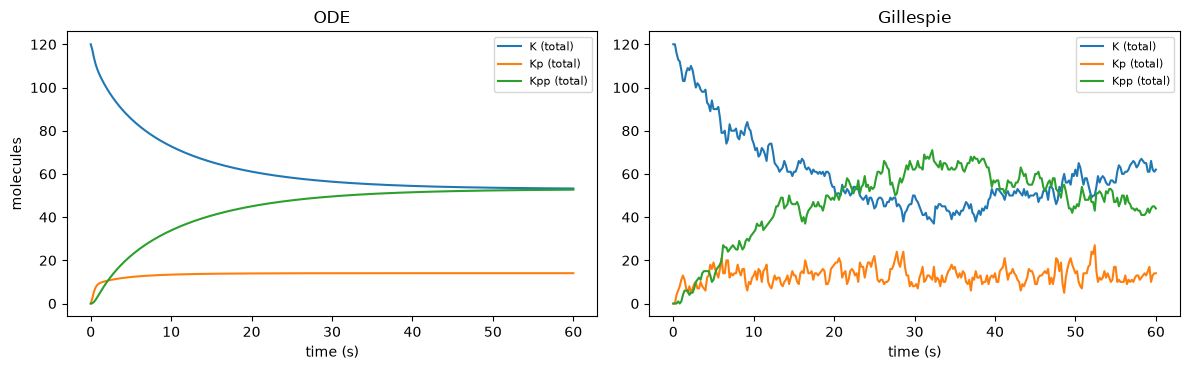

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
targets = {'K (total)': ['K','K_KK'], 'Kp (total)': ['Kp','Kp_KK','Kp_PP'], 'Kpp (total)': ['Kpp','Kpp_PP']}
for ax, solver, title in [(ax1,'ode','ODE'), (ax2,'gillespie','Gillespie')]:
    d = session.run(60.0, ndiv=300, solver=solver).as_df()
    for lab, cols in targets.items():
        ax.plot(d['t'], sum(d[c] for c in cols), label=lab)
    ax.set_xlabel('time (s)'); ax.set_title(title); ax.legend(fontsize=8)
ax1.set_ylabel('molecules'); plt.tight_layout(); plt.show()

## 読み取り

基質 K がキナーゼ KK により **K → Kp → Kpp** と順にリン酸化され、脱リン酸化酵素 PP により **Kpp → Kp → K** と戻る。
総量は各リン酸化状態（遊離＋酵素複合体）を足し合わせて追う。ODE と Gillespie で平均挙動は一致し、後者は分子数ゆらぎを含む。

**要点（公式が教えたい機能）**:
- `@species_attributes` / `@reaction_rules` の**デコレータ**で、状態付き種と多段反応をコンパクトに定義。
- `A + B == AB | (kon, koff) > C | kcat` の**連結記法**で結合⇌解離＋触媒ステップ（酵素反応）を一息に書く。
- MAPK カスケードのような**シグナル伝達モチーフ**の標準的な組み方。